# Notebook 5 - Advanced Model (XGBoost)

This notebook develops and evaluates an XGBoost regression model for predicting residential property close prices.

The workflow uses chronological, leakage-aware training, validation, and testing datasets. Each hyperparameter combination is trained on the training period and evaluated on the separate validation month. After the final configuration is selected, the model is retrained using the combined training and validation datasets and evaluated once on the untouched testing month using R², MAE, MAPE, MdAPE, and RMSE.

## Week 7 Summary

- Trained an XGBoost Regressor to capture complex nonlinear relationships in residential property data.
- Evaluated 27 combinations of `max_depth`, `learning_rate`, and `n_estimators` using the held-out validation month.
- Selected `max_depth = 9`, `learning_rate = 0.08`, and `n_estimators = 900` as the fastest configuration within 0.001 validation R² of the best candidate.
- Retrained the selected configuration using the combined training and validation datasets.
- Achieved a held-out test R² of 0.9026, MAE of USD 156,957.96, MAPE of 12.1629%, MdAPE of 8.2044%, and RMSE of USD 306,452.34.
- XGBoost produced the strongest R², MAE, MAPE, and RMSE among the tested models, while Random Forest retained a slightly lower MdAPE.

## Setup & Load Data

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
import time
from pathlib import Path
# Machine Learning
from xgboost import XGBRegressor
# Evaluation
from sklearn.metrics import (r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error)
# Plot
import matplotlib.pyplot as plt

In [2]:
# Number of historical months used for training
TRAIN_MONTHS = 30

In [3]:
# Load csv files into dataframe
data_dir = Path("../data/cleaned_full")
paths = {
    "train_encoded": data_dir / f"train_encoded_{TRAIN_MONTHS}m.csv",
    "validation_encoded": data_dir / f"validation_encoded_{TRAIN_MONTHS}m.csv",
    "test_encoded": data_dir / f"test_encoded_{TRAIN_MONTHS}m.csv",
}
dfs = {
    name: pd.read_csv(path, low_memory = False)
    for name, path in paths.items()
}
train_encoded_df = dfs["train_encoded"]
validation_encoded_df = dfs["validation_encoded"]
test_encoded_df = dfs["test_encoded"]

# Read the retained transaction periods for an exact split summary
period_source = pd.read_csv(
    data_dir / f"cleaned_crmls_{TRAIN_MONTHS}m.csv",
    usecols = ["ClosePeriod"]
)
available_periods = pd.PeriodIndex(
    period_source["ClosePeriod"].dropna().astype(str),
    freq = "M"
).unique().sort_values()
test_period = available_periods.max()
validation_period = test_period - 1
training_periods = available_periods[available_periods < validation_period]

print(
    f"Training: {training_periods.min()} to {training_periods.max()} "
    f"({len(training_periods)} months)"
)
print(f"Validation: {validation_period} (1 month)")
print(f"Test: {test_period} (1 month)")

Training: 2023-11 to 2026-04 (30 months)
Validation: 2026-05 (1 month)
Test: 2026-06 (1 month)


In [4]:
print("Training Set shape:", train_encoded_df.shape)
print("Validation Set shape:", validation_encoded_df.shape)
print("Test Set shape:", test_encoded_df.shape)

Training Set shape: (317401, 128)
Validation Set shape: (11646, 128)
Test Set shape: (12443, 128)


## Prepare Features and Target

In [5]:
# Training set
x_train = train_encoded_df.drop(columns = ["ClosePrice"])
y_train = train_encoded_df["ClosePrice"]
# Validation set - used only for model/hyperparameter selection
x_validation = validation_encoded_df.drop(columns = ["ClosePrice"])
y_validation = validation_encoded_df["ClosePrice"]
# Test set
x_test = test_encoded_df.drop(columns = ["ClosePrice"])
y_test = test_encoded_df["ClosePrice"]

In [6]:
print(x_train.shape)
print(x_validation.shape)
print(x_test.shape)

(317401, 127)
(11646, 127)
(12443, 127)


## Model-Selection Training Target Summary

In [7]:
target_summary = y_train.describe().reset_index()
target_summary.columns = ["Statistic", "ClosePrice"]
def format_close_price(row):
    if row["Statistic"] == "count":
        return f"{row['ClosePrice']:,.0f}"
    else:
        return f"${row['ClosePrice']:,.2f}"
target_summary["ClosePrice"] = target_summary.apply(format_close_price, axis = 1)
target_summary.style.hide(axis = "index")

Statistic,ClosePrice
count,"317,401"
mean,"$1,189,779.56"
std,"$945,850.98"
min,"$189,000.00"
25%,"$620,000.00"
50%,"$887,000.00"
75%,"$1,415,000.00"
max,"$8,200,000.00"


## Train XGBoost Model

### Build Base Model

In [8]:
# Settings shared by every candidate model
xgb_common_params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1
}

### Hyperparameter Search Space

The search space below evaluates a focused set of values for the three Week 7 hyperparameters. Every combination is fitted on the training period and scored on the same held-out validation month.

The search evaluates:

- `max_depth`: controls the maximum depth of each tree.
- `learning_rate`: controls how strongly each new tree contributes to the model.
- `n_estimators`: controls the total number of boosting trees.

A total of 27 parameter combinations are evaluated. The testing month is not used during this search.

In [9]:
param_grid = {
    "max_depth": [7, 8, 9],
    "learning_rate": [0.08, 0.1, 0.12],
    "n_estimators": [900, 1200, 1500]
}

In [10]:
n_combinations = (
    len(param_grid["max_depth"])
    * len(param_grid["learning_rate"])
    * len(param_grid["n_estimators"])
)
print(f"Parameter combinations to evaluate: {n_combinations}")

Parameter combinations to evaluate: 27


### Hyperparameter Tuning

Each candidate model is fitted using `x_train` and `y_train`, then evaluated using `x_validation` and `y_validation`. Validation R² is the primary selection metric; MAE, MdAPE, RMSE, and fitting time are recorded for comparison.

The testing dataset remains untouched during model selection. This preserves an unbiased final estimate of model performance.

In [11]:
tuning_results = []

for max_depth in param_grid["max_depth"]:
    for learning_rate in param_grid["learning_rate"]:
        for n_estimators in param_grid["n_estimators"]:
            candidate_model = XGBRegressor(
                max_depth = max_depth,
                learning_rate = learning_rate,
                n_estimators = n_estimators,
                **xgb_common_params
            )

            start_time = time.perf_counter()
            candidate_model.fit(x_train, y_train)
            fit_time = time.perf_counter() - start_time

            validation_predictions = candidate_model.predict(x_validation)
            validation_mdape = np.median(
                np.abs((y_validation - validation_predictions) / y_validation)
            ) * 100

            tuning_results.append({
                "Max Depth": max_depth,
                "Learning Rate": learning_rate,
                "N Estimators": n_estimators,
                "Validation R²": r2_score(y_validation, validation_predictions),
                "Validation MAE": mean_absolute_error(y_validation, validation_predictions),
                "Validation MdAPE (%)": validation_mdape,
                "Validation RMSE": root_mean_squared_error(y_validation, validation_predictions),
                "Fit Time (s)": fit_time
            })

            print(
                f"Completed {len(tuning_results):>2}/{n_combinations}: "
                f"depth={max_depth}, learning_rate={learning_rate}, "
                f"n_estimators={n_estimators}"
            )

print("Validation tuning completed!")

Completed  1/27: depth=7, learning_rate=0.08, n_estimators=900
Completed  2/27: depth=7, learning_rate=0.08, n_estimators=1200
Completed  3/27: depth=7, learning_rate=0.08, n_estimators=1500
Completed  4/27: depth=7, learning_rate=0.1, n_estimators=900
Completed  5/27: depth=7, learning_rate=0.1, n_estimators=1200
Completed  6/27: depth=7, learning_rate=0.1, n_estimators=1500
Completed  7/27: depth=7, learning_rate=0.12, n_estimators=900
Completed  8/27: depth=7, learning_rate=0.12, n_estimators=1200
Completed  9/27: depth=7, learning_rate=0.12, n_estimators=1500
Completed 10/27: depth=8, learning_rate=0.08, n_estimators=900
Completed 11/27: depth=8, learning_rate=0.08, n_estimators=1200
Completed 12/27: depth=8, learning_rate=0.08, n_estimators=1500
Completed 13/27: depth=8, learning_rate=0.1, n_estimators=900
Completed 14/27: depth=8, learning_rate=0.1, n_estimators=1200
Completed 15/27: depth=8, learning_rate=0.1, n_estimators=1500
Completed 16/27: depth=8, learning_rate=0.12, n_est

In [12]:
tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by = ["Validation R²", "Validation RMSE"],
    ascending = [False, True]
).reset_index(drop = True)

# Treat candidates within this validation R² distance as practically tied.
R2_TOLERANCE = 0.001
best_validation_r2 = tuning_results_df["Validation R²"].max()
tuning_results_df["Near Best"] = (
    tuning_results_df["Validation R²"]
    >= best_validation_r2 - R2_TOLERANCE
)

near_best_models = tuning_results_df[
    tuning_results_df["Near Best"]
].copy()

selected_xgb_row = near_best_models.sort_values(
    by = ["Fit Time (s)", "Max Depth", "N Estimators"],
    ascending = [True, True, True]
).iloc[0]

selection_reason = (
    "Selected the fastest model within 0.001 validation R² of the "
    "best candidate. Lower model complexity was used as a tie-breaker."
)

best_xgb_params = {
    "max_depth": int(selected_xgb_row["Max Depth"]),
    "learning_rate": float(selected_xgb_row["Learning Rate"]),
    "n_estimators": int(selected_xgb_row["N Estimators"])
}

display(
    tuning_results_df.style.format({
        "Learning Rate": "{:.2f}",
        "Validation R²": "{:.4f}",
        "Validation MAE": "${:,.2f}",
        "Validation MdAPE (%)": "{:.4f}%",
        "Validation RMSE": "${:,.2f}",
        "Fit Time (s)": "{:.2f}"
    }).hide(axis = "index")
)

Max Depth,Learning Rate,N Estimators,Validation R²,Validation MAE,Validation MdAPE (%),Validation RMSE,Fit Time (s),Near Best
9,0.08,1500,0.9034,"$156,043.57",7.9037%,"$303,767.18",26.18,True
9,0.08,1200,0.9031,"$156,789.19",7.9429%,"$304,290.14",21.48,True
7,0.10,1500,0.9026,"$158,957.88",8.2847%,"$305,080.82",19.20,True
8,0.08,1500,0.9025,"$157,364.47",8.0061%,"$305,155.68",22.06,True
9,0.08,900,0.9025,"$157,928.91",8.0043%,"$305,225.41",16.33,True
7,0.12,1500,0.9025,"$159,112.55",8.2381%,"$305,309.13",18.76,True
9,0.12,1500,0.9023,"$156,680.15",7.8238%,"$305,519.23",26.27,False
9,0.12,1200,0.9021,"$157,134.48",7.8924%,"$305,901.19",21.09,False
9,0.10,1200,0.9021,"$156,738.90",7.7978%,"$305,902.46",20.81,False
9,0.10,1500,0.9020,"$156,387.20",7.7796%,"$306,072.08",26.50,False


### Final Parameter Selection

Selecting the configuration with the highest validation score may not provide a meaningful practical advantage when several models perform almost identically.

A model is classified as near-best when its validation R² is within 0.001 of the highest observed validation score. Among these near-best models, the configuration with the shortest fitting time is selected.

If multiple candidates have similar fitting times, lower model complexity is used as a tie-breaker. The validation month is used only for model selection, and the testing month remains untouched until the final model is frozen.

The highest validation R² was 0.9034 for `max_depth = 9`, `learning_rate = 0.08`, and `n_estimators = 1500`. The selected 900-estimator configuration achieved a validation R² of 0.9025, only 0.0009 lower, while reducing fitting time from 26.18 seconds to 16.33 seconds. In this run, this represents approximately 37.6% less fitting time for a very small reduction in validation performance.

In [13]:
print(f"Best Validation R²: {best_validation_r2:.4f}")
print(f"R² tolerance: {R2_TOLERANCE:.4f}")
print(selection_reason)
print("Selected XGBoost parameters:", best_xgb_params)

Best Validation R²: 0.9034
R² tolerance: 0.0010
Selected the fastest model within 0.001 validation R² of the best candidate. Lower model complexity was used as a tie-breaker.
Selected XGBoost parameters: {'max_depth': 9, 'learning_rate': 0.08, 'n_estimators': 900}


### Final Model Training

After hyperparameter selection is complete, the selected XGBoost configuration (`max_depth = 9`, `learning_rate = 0.08`, and `n_estimators = 900`) is retrained using the combined training and validation datasets.

The validation data can now be included because it is no longer being used to make model-selection decisions. The untouched testing month is reserved exclusively for the final evaluation.

In [14]:
final_xgb = XGBRegressor(
    **xgb_common_params,
    **best_xgb_params
)

In [15]:
# Combine training and validation only after hyperparameters are frozen
x_train_final = pd.concat([x_train, x_validation], ignore_index = True)
y_train_final = pd.concat([y_train, y_validation], ignore_index = True)

final_xgb.fit(x_train_final, y_train_final)
print("Final XGBoost training on train + validation completed.")

Final XGBoost training on train + validation completed.


In [16]:
y_pred = final_xgb.predict(x_test)

## Evaluate Model Performance

The final XGBoost model is evaluated on the untouched testing dataset using:

- **R²:** proportion of variation in close prices explained by the model.
- **MAE:** average absolute prediction error in dollars.
- **MAPE:** average absolute percentage prediction error.
- **MdAPE:** median absolute percentage prediction error, which is less sensitive to extreme percentage errors.
- **RMSE:** root mean squared error, which places greater emphasis on large prediction errors.

In [17]:
def evaluation(y_test, y_pred):
    # R-squared
    r2 = r2_score(y_test, y_pred)
    # Other results
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    rmse = root_mean_squared_error(y_test, y_pred)
    return r2, mae, mape, mdape, rmse

In [18]:
r2, mae, mape, mdape, rmse = evaluation(y_test, y_pred)

## Final XGBoost Test Results

In [19]:
# Organize Results to dataframe
model_results = pd.DataFrame({
    "Model": ["XGBoost Regressor"],
    "R²": [r2],
    "MAE": [mae],
    "MAPE (%)": [mape],
    "MdAPE (%)": [mdape],
    "RMSE": [rmse]
})
# Convert to Dataframe
model_results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Model,R²,MAE,MAPE (%),MdAPE (%),RMSE
XGBoost Regressor,0.9026,"$156,957.96",12.1629%,8.2044%,"$306,452.34"


## Actual vs Predicted Plot

### XGBoost

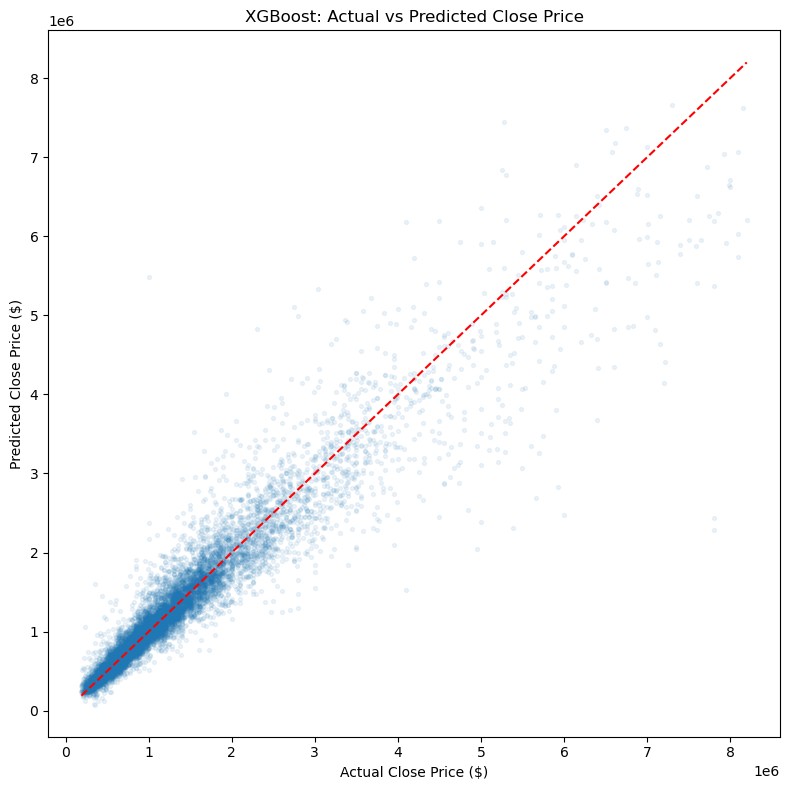

In [20]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred, alpha = 0.08, s = 8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "red", linestyle = "--")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("XGBoost: Actual vs Predicted Close Price")
plt.tight_layout()
plt.show()

## Final Model Performance Comparison

| Model | R² | MAE | MAPE (%) | MdAPE (%) | RMSE |
|---|---:|---:|---:|---:|---:|
| Linear Regression | 0.6410 | USD 358,844.63 | 33.0237% | 24.9839% | USD 588,238.00 |
| Decision Tree Regressor | 0.8131 | USD 210,221.47 | 15.5580% | 10.1449% | USD 424,456.10 |
| Random Forest Regressor | 0.8749 | USD 168,931.31 | 12.4763% | **7.9706%** | USD 347,200.70 |
| XGBoost Regressor | **0.9026** | **USD 156,957.96** | **12.1629%** | 8.2044% | **USD 306,452.34** |

## Advanced Model Evaluation Summary

All models were evaluated under the same chronological train/validation/test design. XGBoost hyperparameters were selected using only the May 2026 validation month. After the configuration was frozen, the model was retrained on the combined training and validation data and evaluated once on the untouched June 2026 testing month.

The selected XGBoost configuration achieved a validation R² of 0.9025 and a test R² of 0.9026, indicating stable performance across the two consecutive held-out months. The test MAE was USD 156,957.96 and the RMSE was USD 306,452.34. The substantially higher RMSE relative to MAE suggests that a smaller number of properties continued to produce large dollar errors.

Compared with Random Forest, XGBoost increased test R² by 0.0277, reduced MAE by USD 11,973.35, reduced MAPE by 0.3134 percentage points, and reduced RMSE by USD 40,748.36. However, Random Forest retained a slightly lower MdAPE: 7.9706% compared with XGBoost's 8.2044%. Therefore, XGBoost improved overall fit and reduced large absolute errors, while Random Forest remained marginally better for the median percentage error.

Overall, XGBoost is the strongest model when prioritizing R², MAE, MAPE, and RMSE. The small MdAPE difference should be retained as a caveat rather than claiming that XGBoost outperformed every prior model on every metric.

---------------------------------------------------------------------------------------------------------------------------------------------------------

## Author

Jasper Fan-Chiang

M.S. in Applied Data Science
University of Southern California

IDX Exchange — Data Science Internship